In [3]:
import warnings

In [6]:
warnings.filterwarnings("ignore")

In [8]:
import pandas as pd

In [10]:
import numpy as np

In [14]:
from sklearn.datasets import load_iris

In [17]:
from sklearn.preprocessing import StandardScaler


In [20]:
raw_iris = load_iris()

In [23]:
features = raw_iris.feature_names

In [26]:
X_raw = raw_iris.data

In [29]:
y_true = raw_iris.target

In [32]:
scaler = StandardScaler()

In [35]:
X_scaled = scaler.fit_transform(X_raw)

In [38]:
iris_df = pd.DataFrame(data=X_scaled, columns=features)

In [41]:
iris_df['species_id'] = y_true

In [44]:
species_map = {i: name for i, name in enumerate(raw_iris.target_names)}

In [47]:
iris_df['species_name'] = iris_df['species_id'].map(species_map)


In [50]:
print("Standardized dataset dimensions:", X_scaled.shape)

Standardized dataset dimensions: (150, 4)


In [53]:
print("\nFirst 3 rows of standardized dataset:")


First 3 rows of standardized dataset:


In [56]:
print(iris_df.head(3))

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0          -0.900681          1.019004          -1.340227         -1.315444   
1          -1.143017         -0.131979          -1.340227         -1.315444   
2          -1.385353          0.328414          -1.397064         -1.315444   

   species_id species_name  
0           0       setosa  
1           0       setosa  
2           0       setosa  


In [59]:
cov_matrix = np.cov(X_scaled.T)

In [62]:
print("Covariance Matrix:\n", cov_matrix)


Covariance Matrix:
 [[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]


In [65]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

In [68]:
print("\nEigenvalues (Variance components):\n", eigenvalues)


Eigenvalues (Variance components):
 [2.93808505 0.9201649  0.14774182 0.02085386]


In [71]:

print("\nEigenvectors (Principal Axes):\n", eigenvectors)



Eigenvectors (Principal Axes):
 [[ 0.52106591 -0.37741762 -0.71956635  0.26128628]
 [-0.26934744 -0.92329566  0.24438178 -0.12350962]
 [ 0.5804131  -0.02449161  0.14212637 -0.80144925]
 [ 0.56485654 -0.06694199  0.63427274  0.52359713]]


In [74]:
from sklearn.decomposition import PCA

In [77]:
pca_model = PCA(n_components=2, random_state=42)

In [81]:
X_pca = pca_model.fit_transform(X_scaled)


In [84]:
pca_df = pd.DataFrame(data=X_pca, columns=['PC_1', 'PC2'])

In [88]:
pca_df['species_name'] = iris_df['species_name']

In [90]:
print("Transformed PCA space dimensions:", X_pca.shape)

Transformed PCA space dimensions: (150, 2)


In [93]:
print("\nFirst 3 projected coordinates:")


First 3 projected coordinates:


In [96]:
print(pca_df.head(3))

       PC_1       PC2 species_name
0 -2.264703  0.480027       setosa
1 -2.080961 -0.674134       setosa
2 -2.364229 -0.341908       setosa


In [99]:
import matplotlib.pyplot as plt

In [102]:
import seaborn as sns

In [105]:
plt.figure(figsize=(6, 4))

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

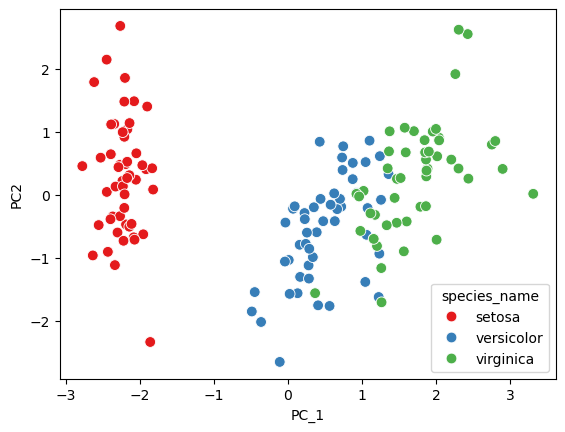

In [119]:
sns.scatterplot(data=pca_df, x='PC_1', y='PC2', hue='species_name', palette='Set1', s=60)
plt.show()

In [122]:
explained_variance = pca_model.explained_variance_ratio_

In [125]:
cumulative_variance = np.sum(explained_variance)

In [128]:
print("Explained Variance per Component:")

Explained Variance per Component:


In [133]:
for i, var in enumerate(explained_variance):
    print(f"  PC{i+1}: {var*100:.2f}%")



  PC1: 72.96%
  PC2: 22.85%


In [135]:
print(f"\nTotal Cumulative Variance Retained by 2 Components: {cumulative_variance*100:.2f}%")



Total Cumulative Variance Retained by 2 Components: 95.81%


In [138]:
import numpy as np

In [141]:
import pandas as pd

In [144]:
import matplotlib.pyplot as plt


In [147]:
from sklearn.datasets import load_iris

In [150]:
from sklearn.model_selection import train_test_split

In [153]:
from sklearn.preprocessing import StandardScaler

In [156]:
from sklearn.decomposition import PCA

In [159]:
from sklearn.linear_model import LogisticRegression


In [162]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [166]:
iris = load_iris()


In [169]:
X = iris.data   

In [172]:
y = iris.target    

In [175]:
feature_names = iris.feature_names

In [178]:
target_names = iris.target_names

In [181]:
print("Dataset Shape:", X.shape)

Dataset Shape: (150, 4)


In [184]:
print("Features:", feature_names)

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [187]:
print("Classes:", target_names)

Classes: ['setosa' 'versicolor' 'virginica']


In [190]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [193]:
scaler = StandardScaler()

In [196]:
X_train_scaled = scaler.fit_transform(X_train)

In [199]:
X_test_scaled = scaler.transform(X_test)

In [202]:
print("\n========================================")
print("CLASSIFICATION WITHOUT PCA")
print("========================================")



CLASSIFICATION WITHOUT PCA


In [205]:
model_without_pca = LogisticRegression(
    random_state=42,
    max_iter=1000
)


In [208]:
model_without_pca.fit(
    X_train_scaled,
    y_train
)


LogisticRegression(max_iter=1000, random_state=42)

In [211]:
y_pred_without_pca = model_without_pca.predict(
    X_test_scaled
)


In [214]:
accuracy_without_pca = accuracy_score(
    y_test,
    y_pred_without_pca
)

In [217]:
print("Accuracy without PCA:",
      accuracy_without_pca)

Accuracy without PCA: 0.9333333333333333


In [220]:

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_without_pca,
        target_names=target_names
    )
)



Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [223]:
print("\n========================================")
print("CLASSIFICATION WITH PCA")
print("========================================")



CLASSIFICATION WITH PCA


In [226]:
pca = PCA(
    n_components=2
)


In [229]:
X_train_pca = pca.fit_transform(
    X_train_scaled
)

In [232]:
# Transform test data using the same PCA
X_test_pca = pca.transform(
    X_test_scaled
)


In [235]:
print("Explained Variance Ratio:",
      pca.explained_variance_ratio_)


Explained Variance Ratio: [0.72677234 0.23066667]


In [238]:
print("Total Explained Variance:",
      pca.explained_variance_ratio_.sum())


Total Explained Variance: 0.9574390106545367


In [241]:
model_with_pca = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [244]:
model_with_pca.fit(
    X_train_pca,
    y_train
)


LogisticRegression(max_iter=1000, random_state=42)

In [247]:
y_pred_with_pca = model_with_pca.predict(
    X_test_pca
)


In [250]:
accuracy_with_pca = accuracy_score(
    y_test,
    y_pred_with_pca
)

In [253]:
print("Accuracy with PCA:",
      accuracy_with_pca)


Accuracy with PCA: 0.9


In [256]:
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_with_pca,
        target_names=target_names
    )
)



Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



In [259]:
print("\n========================================")
print("COMPARISON")
print("========================================")



COMPARISON


In [289]:
comparison = pd.DataFrame({
    "Method": [
        "Without PCA",
        "With PCA"
    ],
    "Number of Features": [
        X_train_scaled.shape[1],
        X_train_pca.shape[1]
    ],
    "Accuracy": [
        accuracy_without_pca,
        accuracy_with_pca
    ]
})


In [291]:
print(comparison)

        Method  Number of Features  Accuracy
0  Without PCA                   4  0.933333
1     With PCA                   2  0.900000


In [293]:
plt.figure(figsize=(8, 6))


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

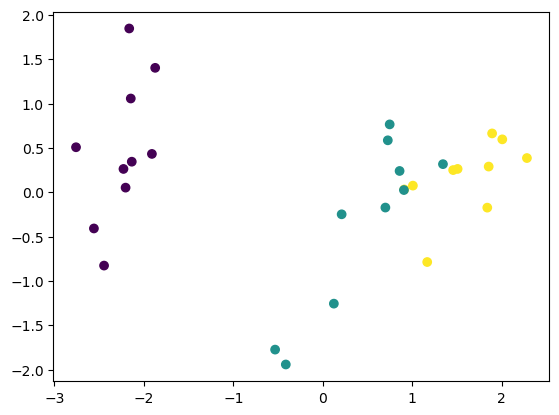

In [295]:
plt.scatter(
    X_test_pca[:, 0],
    X_test_pca[:, 1],
    c=y_test
)

Text(0.5, 0, 'Principal Component 1')

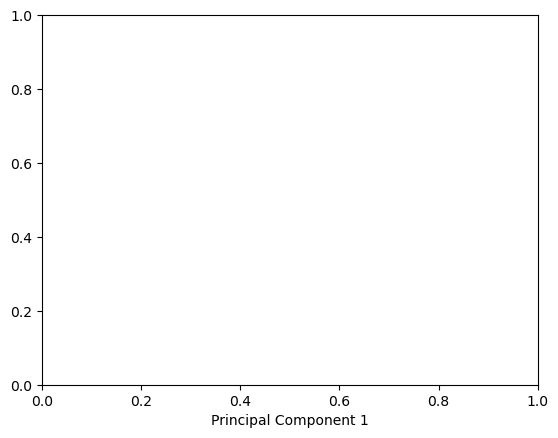

In [297]:
plt.xlabel("Principal Component 1")

Text(0, 0.5, 'Principal Component 2')

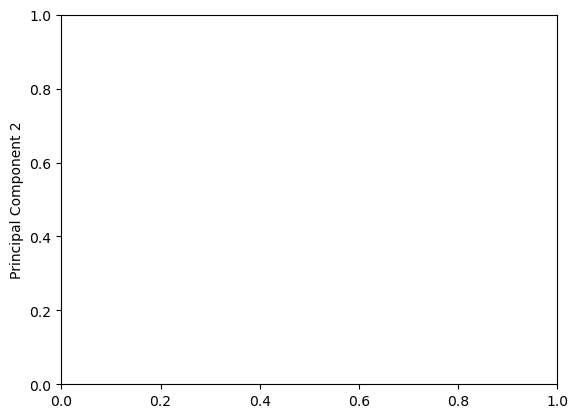

In [299]:
plt.ylabel("Principal Component 2")

Text(0.5, 1.0, 'Iris Classification Using PCA')

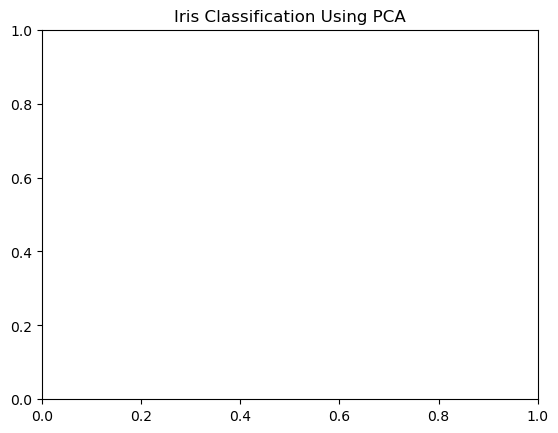

In [301]:
plt.title("Iris Classification Using PCA")

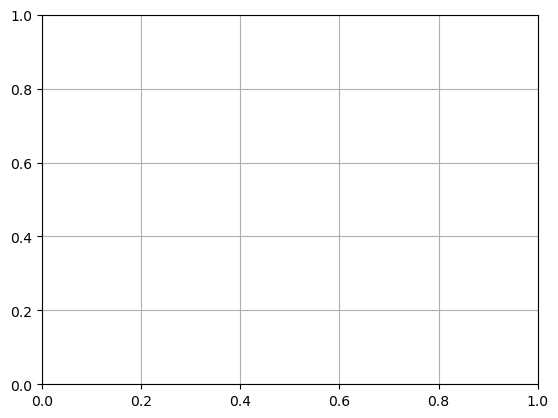

In [302]:
plt.grid()

plt.show()